### MNIST Dataset: Handwritten Digit Images

We load the MNIST dataset of 28×28 grayscale images of handwritten digits (0–9), split into training and test sets.

To get a quick overview, we select one example image for each digit from the training data and display them in a single row. This provides a first visual impression of the dataset and its variability.

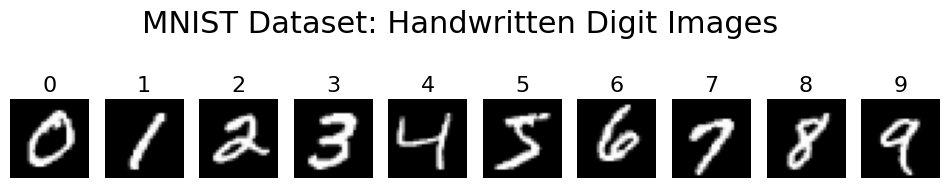

In [4]:
#%pip install numpy matplotlib tensorflow torch
import numpy as np
import matplotlib.pyplot as plt
# from tensorflow.keras.datasets import mnist
import tensorflow as tf
mnist = tf.keras.datasets.mnist

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# total size
n_train = x_train.shape[0]
n_test = x_test.shape[0]
n_total = n_train + n_test

# ------------------------------------------------------------
# pick one example of each digit
# ------------------------------------------------------------
examples = []

for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    examples.append(x_train[idx])

# ------------------------------------------------------------
# create figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(12,5))

gs = fig.add_gridspec(2, 10, height_ratios=[1,1.2])

# title
fig.suptitle("MNIST Dataset: Handwritten Digit Images", fontsize=22)

# ------------------------------------------------------------
# row of example digits
# ------------------------------------------------------------
for i in range(10):

    ax = fig.add_subplot(gs[0,i])

    ax.imshow(examples[i], cmap="gray")
    ax.set_title(str(i), fontsize=16)
    ax.axis("off")


# MNIST Digit Classification with a Simple Feedforward Network

This notebook demonstrates how to build and train a simple feedforward neural network to classify handwritten digits from the MNIST dataset. We will explore both binary classification (distinguishing between two digits) and ternary classification (distinguishing between three digits), using feature engineering and one-hot encoding for labels.

## Initial Setup and Data Loading

First, we the dimensions of some example images to get a feel for the data. Note that MNIST images are of type uint8 with values from 0, 1,...,255 which is not well suited for machine learning purposes. We therefore normalizethe images by converting them to floats and deviding pixel values by 255.

In [15]:
import numpy as np
import torch
print("Datatype and max value: ",x_train.dtype, np.max(x_train))
# Normalize image data (0-255 to 0.0-1.0)
x_train_norm = x_train.astype(np.float32) / 255.0
y_train_orig = y_train
x_test_norm = x_test.astype(np.float32) / 255.0
y_test_orig = y_test

y_train_orig=torch.from_numpy(y_train_orig)
y_test_orig=torch.from_numpy(y_test_orig)


print(f'Shape of normalized training images: {x_train_norm.shape}')
print(f'Shape of normalized test images: {x_test_norm.shape}')

Datatype and max value:  uint8 255
Shape of normalized training images: (60000, 28, 28)
Shape of normalized test images: (10000, 28, 28)


### Feature Extraction

We extract simple features from each image:

- **Average gray value** (overall brightness)
- **Average horizontal edge strength**, computed from differences between neighboring rows

These two features are combined into a 2D feature vector for each image and converted into PyTorch tensors for both training and test sets.

Finally, we visualize the feature space for a subset of samples using a scatter plot, where each point represents an image and colors indicate the digit label.

Shape of full feature tensor (X_full): torch.Size([60000, 2])


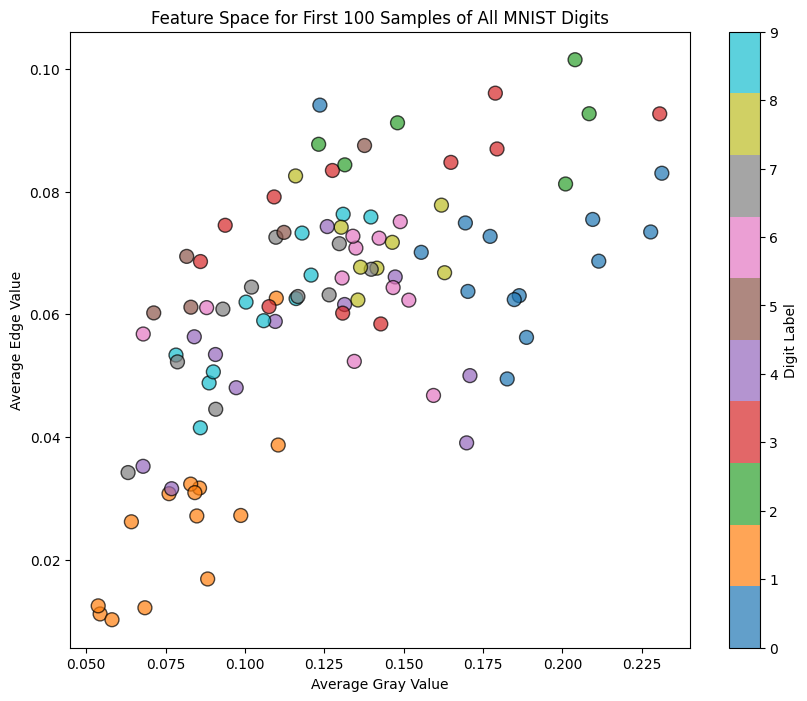

In [ ]:
# The horizontal_edge_image function was previously defined in ZCKVwNl5Rqku.
# It will now be applied to the full normalized training set.

def horizontal_edge_image(img):
    edge = np.zeros_like(img, dtype=np.float32)
    edge[:-1, :] = np.abs(img[1:, :] - img[:-1, :])
    return edge

# Extract features for the full training dataset
edge_imgs_full = np.array([horizontal_edge_image(img) for img in x_train_norm])
avg_gray_full = x_train_norm.mean(axis=(1, 2))
avg_edge_full = edge_imgs_full.mean(axis=(1, 2))

# Combine features into a single PyTorch tensor for the full dataset
X_full = torch.stack((torch.from_numpy(avg_gray_full), torch.from_numpy(avg_edge_full)), axis=1)


# Extract features for the full test dataset
edge_imgs_full_test = np.array([horizontal_edge_image(img) for img in x_test_norm])
avg_gray_full_test = x_test_norm.mean(axis=(1, 2))
avg_edge_full_test = edge_imgs_full_test.mean(axis=(1, 2))

# Combine features into a single PyTorch tensor for the full dataset
X_full_test = torch.stack((torch.from_numpy(avg_gray_full_test), torch.from_numpy(avg_edge_full_test)), axis=1)

print(f'Shape of full feature tensor (X_full): {X_full.shape}')

# Display a scatter plot for a small subset of the full data (e.g., first 100 samples) for all 10 digits
# This helps visualize the feature space before any subsetting
plt.figure(figsize=(10, 8))
scatter = plt.scatter(avg_gray_full[:100], avg_edge_full[:100], c=y_train_orig[:100], cmap='tab10', s=100, alpha=0.7, edgecolor='k')
plt.xlabel('Average Gray Value')
plt.ylabel('Average Edge Value')
plt.title('Feature Space for First 100 Samples of All MNIST Digits')
plt.colorbar(scatter, ticks=range(10), label='Digit Label')
plt.show()

## Feedforward Network Architecture

Here, we define a generic `FeedforwardNet` class that we will reuse for both binary and ternary classification tasks. It consists of a single hidden layer with ReLU activation and an output layer with Softmax for probability distribution over classes.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class FeedforwardNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(FeedforwardNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU() # Using ReLU as the activation function for the hidden layer
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = F.softmax(out, dim=1) # Apply softmax across the class dimension
        return out

print('FeedforwardNet class defined and ready for use (with final softmax).')

FeedforwardNet class defined and ready for use (with final softmax).


### Model Training (Digits 1 vs 7)

We train a feedforward neural network to distinguish between the digits **1 and 7**.

- The dataset is filtered to only include samples of these two digits.
- Each label is encoded as a two-dimensional vector.
- The input consists of the previously extracted 2D features.

Training setup:
- Optimizer: Adam
- Learning rate: 0.01
- Number of epochs: 1000

The model outputs probabilities, and the loss is computed using a log-likelihood formulation. During training, the loss is printed every 100 epochs to monitor convergence.

In [ ]:
import torch.optim as optim

# Instantiate the model (already done in previous cell)
model = FeedforwardNet(2, 100, 2)


pos=torch.logical_or(y_train_orig==1, y_train_orig==7)
X=X_full[pos]
Y=torch.stack((y_train_orig==1,y_train_orig==7),axis=1)
Y=Y[pos]


pos_test=torch.logical_or(y_test_orig==1, y_test_orig==7)
X_test=X_full_test[pos_test]
Y_test=torch.stack((y_test_orig==1,y_test_orig==7),axis=1)
Y_test=Y_test[pos_test]



# Define loss function and optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Number of epochs for training
num_epochs = 1000

# Training loop
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X.float()) # Ensure input is float

    # Use cross entropy to quantify error
    loss = -(Y.float() * torch.log(outputs+1e-10)).sum(dim=1).mean()

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 100 == 0:
        print(outputs.dtype,Y.float().dtype,(Y * torch.log(outputs)).sum(dim=1).shape)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

print('Training finished.')

torch.float32 torch.float32 torch.Size([13007])
Epoch [100/1000], Loss: 0.3359
torch.float32 torch.float32 torch.Size([13007])
Epoch [200/1000], Loss: 0.2364
torch.float32 torch.float32 torch.Size([13007])
Epoch [300/1000], Loss: 0.2009
torch.float32 torch.float32 torch.Size([13007])
Epoch [400/1000], Loss: 0.1953
torch.float32 torch.float32 torch.Size([13007])
Epoch [500/1000], Loss: 0.1943
torch.float32 torch.float32 torch.Size([13007])
Epoch [600/1000], Loss: 0.1939
torch.float32 torch.float32 torch.Size([13007])
Epoch [700/1000], Loss: 0.1936
torch.float32 torch.float32 torch.Size([13007])
Epoch [800/1000], Loss: 0.1933
torch.float32 torch.float32 torch.Size([13007])
Epoch [900/1000], Loss: 0.1931
torch.float32 torch.float32 torch.Size([13007])
Epoch [1000/1000], Loss: 0.1928
Training finished.


### Model Evaluation

We evaluate the trained model on the test set (digits 1 and 7 only).

- The model is set to evaluation mode and predictions are computed without gradient tracking.
- Predicted classes are obtained by selecting the highest output probability.
- Accuracy is calculated by comparing predictions with the true labels.

This provides a quantitative measure of how well the model distinguishes between the two digits.

In [ ]:
print('--- Calculating Binary Model Accuracy ---')

model.eval()

with torch.no_grad():
    outputs_binary = model(X_test.float())
    _, predicted_binary = torch.max(outputs_binary.data, 1)

# Create a 1D tensor of class indices for the true labels for comparison
# Map DIGITS_BINARY[0] to 0 and DIGITS_BINARY[1] to 1

total_binary = Y_test.size(0)
correct_binary = (predicted_binary == Y_test[:,1]).sum().item()
accuracy_binary = 100 * correct_binary / total_binary

print(f'Accuracy of the binary model on the training data (digits 1 and 7): {accuracy_binary:.2f}%')
print('Accuracy calculation complete.')

--- Calculating Binary Model Accuracy ---
Accuracy of the binary model on the training data (digits 1 and 7): 92.05%
Accuracy calculation complete.


### Decision Boundary Visualization

We visualize how the trained model separates digits **1 and 7** in the 2D feature space.

- A grid over the feature space (average gray value and edge strength) is created.
- The model predicts a class for each point on this grid.
- The resulting regions are plotted as a decision boundary.

The test data points are overlaid, allowing us to see how well the model separates the two classes.

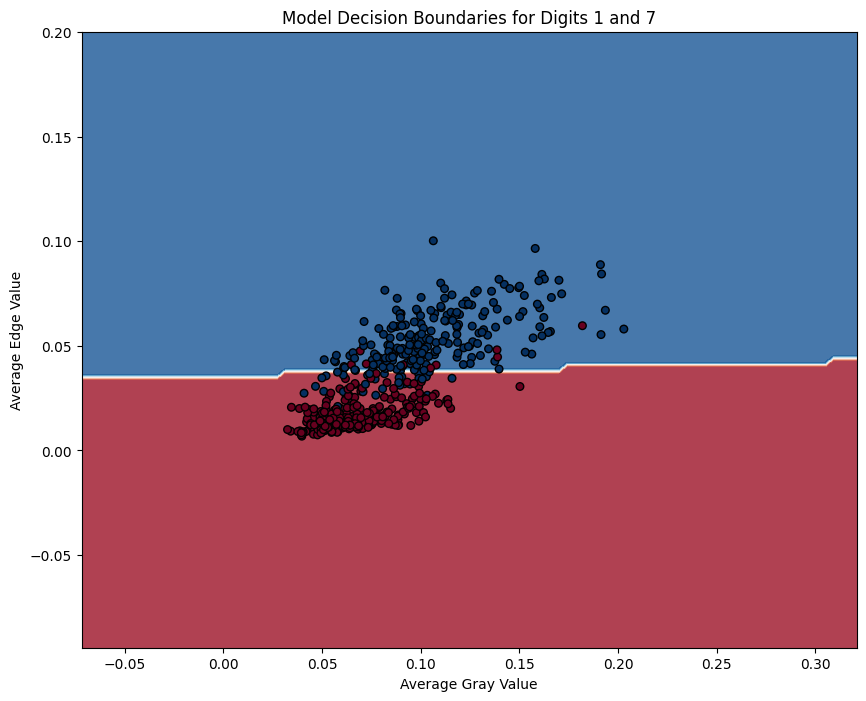

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Put the model in evaluation mode
model.eval()

# Convert features to numpy for plotting
avg_gray_np = X_test[:, 0].cpu().numpy()
avg_edge_np = X_test[:, 1].cpu().numpy()
Y_np = Y.cpu().numpy()

# Create a meshgrid for plotting decision boundaries
x_min, x_max = avg_gray_np.min() - 0.1, avg_gray_np.max() + 0.1
y_min, y_max = avg_edge_np.min() - 0.1, avg_edge_np.max() + 0.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Predict on the meshgrid
meshgrid_features = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    Z = model(meshgrid_features)
    _, Z = torch.max(Z, 1) # Get the predicted class (0 or 1)
    Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)

# Plot the original data points
# Map original Y values (1 and 7) to 0 and 1 for plotting consistency
mapped_Y_for_plot = np.argmax(Y_test, axis=1)

# plt.scatter(X_full_test[:50,0], X_full_test[:50,1], c=mapped_Y_for_plot[:50], s=30, edgecolor='k', cmap=plt.cm.RdBu)
plt.scatter(X_test[:500,0], X_test[:500,1], c=mapped_Y_for_plot[:500], s=30, edgecolor='k', cmap=plt.cm.RdBu)

plt.xlabel('Average Gray Value')
plt.ylabel('Average Edge Value')
plt.title('Model Decision Boundaries for Digits 1 and 7')

plt.savefig('decision_boundary_1_vs_7.pdf') # Save the figure as a PDF
plt.show()

### Model Training (Digits 1, 6, and 7)

We extend the classification task to three digits: **1, 6, and 7**.

- The dataset is filtered to include only these digits.
- Labels are encoded as three-dimensional vectors (one-hot encoding).
- The input remains the 2D feature representation.

Training setup:
- Model output dimension: 3 classes
- Optimizer: Adam (learning rate 0.01)
- Number of epochs: 1000

The model is trained using a log-likelihood loss, and the loss is printed every 100 epochs to track progress.

In [ ]:
import torch.optim as optim

# Instantiate the model (already done in previous cell)
model = FeedforwardNet(2, 100, 3)


pos=torch.logical_or(y_train_orig==1, y_train_orig==7)
pos=torch.logical_or(pos, y_train_orig==6)
X=X_full[pos]
Y=torch.stack(((y_train_orig[pos]==1).float(),(y_train_orig[pos]==7).float(),(y_train_orig[pos]==6).float()),axis=1)


pos_test=torch.logical_or(y_test_orig==1, y_test_orig==7)
pos_test=torch.logical_or(pos_test, y_test_orig==6)

X_test=X_full_test[pos_test]
Y_test=torch.stack(((y_test_orig[pos_test]==1).float(),(y_test_orig[pos_test]==7).float(),(y_test_orig[pos_test]==6).float()),axis=1)



# Define loss function and optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Number of epochs for training
num_epochs = 1000

# Training loop
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X.float()) # Ensure input is float

    loss = -(Y.float() * torch.log(outputs+1e-10)).sum(dim=1).mean()


    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

print('Training finished.')

Epoch [100/1000], Loss: 0.6622
Epoch [200/1000], Loss: 0.5822
Epoch [300/1000], Loss: 0.5583
Epoch [400/1000], Loss: 0.5549
Epoch [500/1000], Loss: 0.5544
Epoch [600/1000], Loss: 0.5541
Epoch [700/1000], Loss: 0.5538
Epoch [800/1000], Loss: 0.5536
Epoch [900/1000], Loss: 0.5533
Epoch [1000/1000], Loss: 0.5530
Training finished.


### Model Evaluation (Digits 1, 6, and 7)

We evaluate the trained model on the test set for the three-class problem.

- The model predicts the most likely class for each sample.
- True labels are obtained from the one-hot encoded targets.
- Accuracy is computed as the fraction of correct predictions.

This measures how well the model distinguishes between digits **1, 6, and 7**.

In [ ]:
print('--- Calculating Ternary Model Accuracy ---')

model.eval() # Put the model in evaluation mode

with torch.no_grad():
    outputs = model(X_test.float())
    _, predicted_labels = torch.max(outputs, 1)

_, true_labels=torch.max(Y_test,1)

print("here",predicted_labels,true_labels)

accuracy=torch.mean((predicted_labels==true_labels).float())
accuracy_ternary=accuracy.item()*100


print(f'Accuracy of the ternary model on the test data (digits 1, 6, 7): {accuracy_ternary:.2f}%')
print('Accuracy calculation complete.')

--- Calculating Ternary Model Accuracy ---
here tensor([1, 0, 0,  ..., 1, 0, 2]) tensor([1, 0, 0,  ..., 1, 0, 2])
Accuracy of the ternary model on the test data (digits 1, 6, 7): 73.47%
Accuracy calculation complete.


### Decision Boundary Visualization (Digits 1, 6, and 7)

We visualize how the trained model partitions the 2D feature space for the three-class problem.

- A mesh grid is created over the feature space.
- The model predicts a class for each grid point.
- The resulting prediction regions are shown as colored decision areas.

The training samples are plotted on top, making it possible to compare the learned class regions with the actual distribution of digits **1**, **6**, and **7** in feature space.

--- Visualizing Ternary Model Decision Boundaries ---


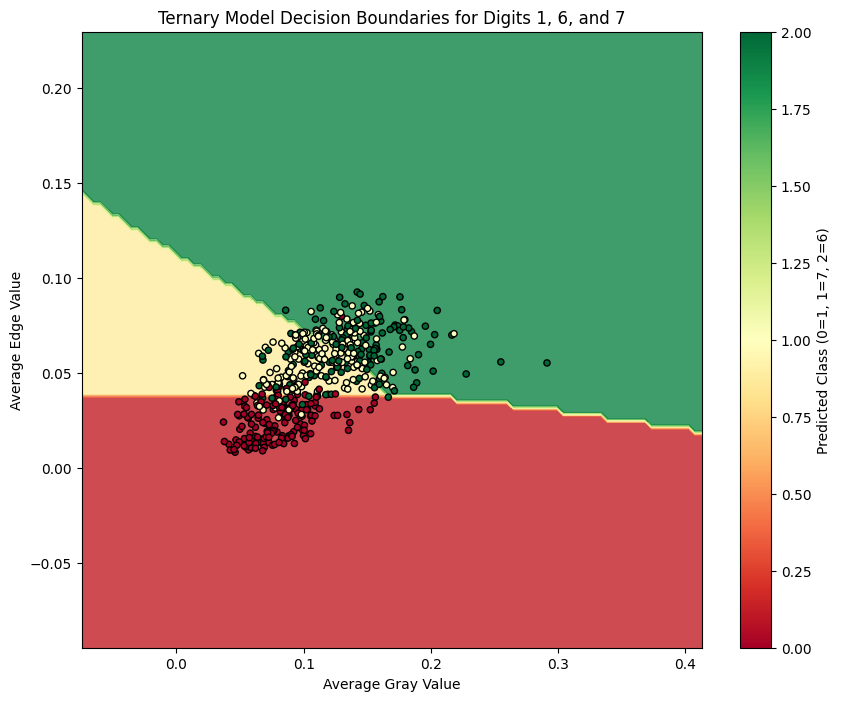

Decision boundary visualization complete.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print('--- Visualizing Ternary Model Decision Boundaries ---')

# Put the model in evaluation mode
model.eval()

# Define the digits used for ternary classification (ensure this list is available)
DIGITS_TERNARY = [1, 7, 6] # Based on the setup in cell 00wbsggYeqO-

# Convert features and original labels (from the training set X and Y) to numpy arrays for plotting
avg_gray_np_ternary = X[:, 0].cpu().numpy()
avg_edge_np_ternary = X[:, 1].cpu().numpy()
Y_np_ternary_original_labels = y_train_orig[pos].cpu().numpy() # Use original labels for scatter coloring

# Create a meshgrid to cover the entire feature space for plotting decision boundaries
x_min_t, x_max_t = avg_gray_np_ternary.min() - 0.1, avg_gray_np_ternary.max() + 0.1
y_min_t, y_max_t = avg_edge_np_ternary.min() - 0.1, avg_edge_np_ternary.max() + 0.1
xx_t, yy_t = np.meshgrid(np.linspace(x_min_t, x_max_t, 100), np.linspace(y_min_t, y_max_t, 100))

# Predict the class for each point on the meshgrid using the trained ternary model
meshgrid_features_ternary = torch.tensor(np.c_[xx_t.ravel(), yy_t.ravel()], dtype=torch.float32)
with torch.no_grad(): # Disable gradient calculation for inference
    Z_ternary = model(meshgrid_features_ternary) # Use the current 'model' for prediction
    _, Z_ternary = torch.max(Z_ternary, 1) # Get the predicted class index (0, 1, or 2)
    Z_ternary = Z_ternary.reshape(xx_t.shape) # Reshape predictions back to grid format

# Plot the decision boundary regions
plt.figure(figsize=(10, 8))
plt.contourf(xx_t, yy_t, Z_ternary, alpha=0.8, cmap=plt.cm.RdYlGn) # RdYlGn is a good colormap for 3 classes

# Map original Y values (1, 7, 6) to 0, 1, 2 for consistent plotting with Z_ternary
# Ensure the mapping matches the order used when creating the one-hot encoded labels in training (1, 7, 6)
digit_to_class_map_ternary = {DIGITS_TERNARY[0]: 0, DIGITS_TERNARY[1]: 1, DIGITS_TERNARY[2]: 2}
mapped_Y_for_plot_ternary = np.array([digit_to_class_map_ternary[d] for d in Y_np_ternary_original_labels])

# Plot the original data points on top of the decision boundaries
plt.scatter(avg_gray_np_ternary[:500], avg_edge_np_ternary[:500], c=mapped_Y_for_plot_ternary[:500], s=20, edgecolor='k', cmap=plt.cm.RdYlGn)

plt.xlabel('Average Gray Value')
plt.ylabel('Average Edge Value')
plt.title('Ternary Model Decision Boundaries for Digits 1, 6, and 7')
# Add a colorbar to explain what each color represents
plt.colorbar(label=f'Predicted Class (0={DIGITS_TERNARY[0]}, 1={DIGITS_TERNARY[1]}, 2={DIGITS_TERNARY[2]})')
plt.savefig('decision_boundary_1_6_7.pdf') # Save the figure as a PDF
plt.show()
print('Decision boundary visualization complete.')

### Convolutional Neural Network (CNN)

We define a convolutional neural network for image classification.

Architecture:
- A **convolutional layer** extracts local features from the input images
- A **ReLU activation** introduces non-linearity
- A **max-pooling layer** reduces spatial dimensions and retains important features
- The result is **flattened** and passed through two fully connected layers
- A final **softmax layer** outputs class probabilities

The model automatically reshapes input images to match the expected format and computes the correct size for the fully connected layers based on the image dimensions.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class ConvNetClassifier(nn.Module):
    def __init__(self, input_channels, num_filters, kernel_size, hidden_size, output_size, image_size=(28, 28)):
        super(ConvNetClassifier, self).__init__()
        # First Convolutional Layer
        self.conv1 = nn.Conv2d(input_channels, num_filters, kernel_size=kernel_size)
        self.relu1 = nn.ReLU()

        # Pooling Layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Added a Max Pooling layer

        # Calculate the output size of the convolutional and pooling layers after flattening
        # Assuming stride=1, padding=0 for conv1
        conv_output_height = image_size[0] - kernel_size + 1
        conv_output_width = image_size[1] - kernel_size + 1

        # After pooling (kernel_size=2, stride=2)
        pooled_output_height = conv_output_height // 2 # Integer division for pooling
        pooled_output_width = conv_output_width // 2 # Integer division for pooling

        flattened_size = num_filters * pooled_output_height * pooled_output_width

        # Fully Connected Layers
        self.fc1 = nn.Linear(flattened_size, hidden_size)
        self.relu2 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Reshape input for Conv2d: (batch_size, channels, height, width)
        if len(x.shape) == 3: # If input is (batch_size, height, width)
            x = x.unsqueeze(1) # Add channel dimension: (batch_size, 1, height, width)
        elif len(x.shape) == 2:
            raise ValueError("ConvNetClassifier expects image-like input (3D or 4D).")

        out = self.conv1(x)
        out = self.relu1(out)
        out = self.pool(out) # Apply pooling
        out = out.view(out.size(0), -1) # Flatten the output for the dense layers
        out = self.fc1(out)
        out = self.relu2(out)
        out = self.fc2(out)
        out = F.softmax(out, dim=1) # Apply softmax across the class dimension
        return out

print('ConvNetClassifier class defined and ready for use with pooling and softmax.')

ConvNetClassifier class defined and ready for use with pooling and softmax.


### Training the CNN (Digits 1, 6, and 7)

We now train the convolutional neural network on the original MNIST images for the digits **1**, **6**, and **7**.

- The training and test sets are filtered to include only these three classes.
- The input to the model is the full normalized image, not the reduced 2D feature representation.
- The CNN outputs class probabilities for the three digits.

Training setup:
- Optimizer: Adam
- Learning rate: 0.001
- Number of epochs: 10

During training, the loss is printed after each epoch to monitor learning progress.

In [ ]:
import torch.optim as optim

print('--- Defining and Training the ConvNetClassifier Model for Digits 1, 6, and 7 ---')

# Define the specific digits for this classification task
DIGITS_CNN_TERNARY = [1, 6, 7]

# Filter the training data for only these digits
mask_train_cnn = np.isin(y_train_orig.numpy(), DIGITS_CNN_TERNARY)
X = torch.from_numpy(x_train_norm[mask_train_cnn])

mask_test_cnn = np.isin(y_test_orig.numpy(), DIGITS_CNN_TERNARY)
X_test=torch.from_numpy(x_test_norm[mask_test_cnn])


# Model Parameters
input_channels = 1 # MNIST images are grayscale, so 1 channel
num_filters = 10   # Number of filters in the convolutional layer
kernel_size = 3    # Size of the convolutional kernel (e.g., 5x5)
hidden_size_cnn = 100 # Hidden layer size for the dense part
output_size_cnn = len(DIGITS_CNN_TERNARY) # 3 digits (1, 6, 7) for classification
image_size_cnn = x_train_norm.shape[1:] # (28, 28)

# Instantiate the ConvNetClassifier model
model = ConvNetClassifier(input_channels, num_filters, kernel_size, hidden_size_cnn, output_size_cnn, image_size_cnn)

outputs=model(X)
print("outputs", outputs.shape)

# Define loss function and optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Number of epochs for training
num_epochs_cnn = 10

# Map original digit values (1, 6, 7) to class indices (0, 1, 2) for loss calculation
digit_to_class_map_cnn = {digit: i for i, digit in enumerate(DIGITS_CNN_TERNARY)}

# Training loop
print('Training ConvNetClassifier...')
for epoch in range(num_epochs_cnn):
    # Reshape input for Conv2D: (batch_size, channels, height, width)
    outputs = model(X)


    loss = -(Y.float() * torch.log(outputs+1e-10)).sum(dim=1).mean()


    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 1 == 0: # Print loss every epoch
        print(f'Epoch [{epoch+1}/{num_epochs_cnn}], Loss: {loss.item():.4f}')

print('ConvNetClassifier Training finished.')

--- Defining and Training the ConvNetClassifier Model for Digits 1, 6, and 7 ---
outputs torch.Size([18925, 3])
Training ConvNetClassifier...
Epoch [1/10], Loss: 1.1040
Epoch [2/10], Loss: 0.9937
Epoch [3/10], Loss: 0.8882
Epoch [4/10], Loss: 0.7846
Epoch [5/10], Loss: 0.6868
Epoch [6/10], Loss: 0.5963
Epoch [7/10], Loss: 0.5136
Epoch [8/10], Loss: 0.4397
Epoch [9/10], Loss: 0.3756
Epoch [10/10], Loss: 0.3208
ConvNetClassifier Training finished.


### Model Evaluation (CNN)

We evaluate the trained convolutional neural network on the test set for digits **1, 6, and 7**.

- The model predicts the most likely class for each image.
- True labels are obtained from the one-hot encoded targets.
- Accuracy is computed as the proportion of correct predictions.

This shows how well the CNN performs compared to the simpler feature-based model.

In [ ]:
print('--- Calculating Ternary Model Accuracy ---')

model.eval() # Put the model in evaluation mode

with torch.no_grad():
    outputs = model(X_test.float())
    _, predicted_labels = torch.max(outputs, 1)

_, true_labels=torch.max(Y_test,1)

print("here",predicted_labels,true_labels)

accuracy=torch.mean((predicted_labels==true_labels).float())
accuracy_ternary=accuracy.item()*100


print(f'Accuracy of the ternary model on the test data (digits 1, 6, 7): {accuracy_ternary:.2f}%')
print('Accuracy calculation complete.')

--- Calculating Ternary Model Accuracy ---
here tensor([1, 0, 0,  ..., 1, 0, 2]) tensor([1, 0, 0,  ..., 1, 0, 2])
Accuracy of the ternary model on the test data (digits 1, 6, 7): 96.28%
Accuracy calculation complete.
